In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

from pathlib import Path

sns.set_theme(style="whitegrid")

In [8]:
nav_history = pd.read_csv(
    "../data/processed/nav_history_cleaned.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

benchmark = pd.read_csv(
    "../data/processed/benchmark_indices_cleaned.csv"
)

fund_master = pd.read_csv(
    "../data/processed/fund_master_cleaned.csv"
)

In [9]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

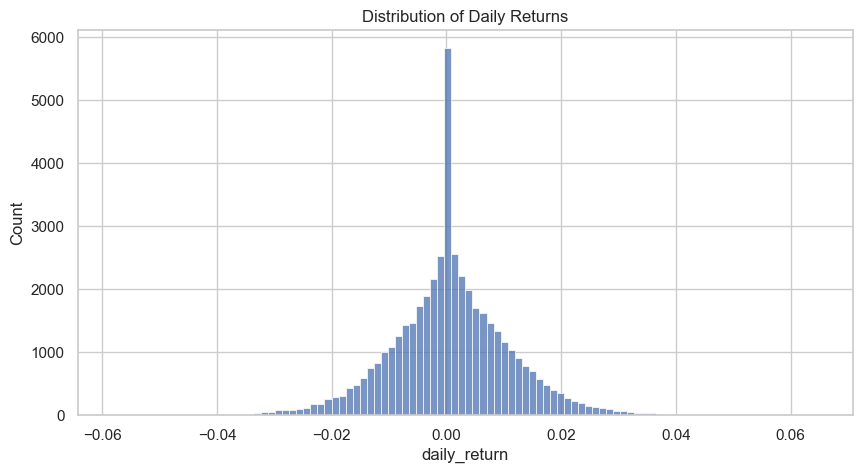

In [10]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)
plt.figure(figsize=(10,5))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Returns")

plt.show()

# CAGR Comparison Analysis

In [45]:
cagr_comparison = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    df = df.sort_values("date")

    latest_nav = df.iloc[-1]["nav"]

    latest_date = df.iloc[-1]["date"]

    result = {
        "amfi_code": fund
    }

    for years in [1, 3, 5]:

        target_date = latest_date - pd.DateOffset(years=years)

        historical = df[
            df["date"] >= target_date
        ]

        if len(historical) > 1:

            start_nav = historical.iloc[0]["nav"]

            cagr = (
                (latest_nav / start_nav)
                ** (1 / years)
                - 1
            )

            result[f"cagr_{years}yr"] = cagr

        else:

            result[f"cagr_{years}yr"] = np.nan

    cagr_comparison.append(result)

cagr_comparison_df = pd.DataFrame(
    cagr_comparison
)

cagr_comparison_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [46]:
cagr_comparison_df = cagr_comparison_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code"
)

cagr_comparison_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth


In [47]:
cagr_comparison_df.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
16,119094,0.222611,0.351118,0.244453,Axis Midcap Fund - Regular - Growth
34,148567,0.203607,0.340009,0.267993,Mirae Asset Large Cap Fund - Regular - Growth
24,120504,0.130643,0.324874,0.202340,ICICI Pru Bluechip Fund - Direct - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,0.296047,0.317775,0.283768,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.604373,0.304565,0.223849,SBI Bluechip Fund - Regular Plan - Growth
30,120843,0.266571,0.295828,0.267425,Kotak Flexicap Fund - Regular - Growth
36,148569,0.397518,0.291789,0.276299,Mirae Asset Tax Saver Fund - Regular - Growth
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
39,149324,0.651387,0.270004,0.279174,DSP Small Cap Fund - Regular - Growth


In [11]:
cagr_results = []
for fund in nav_history["amfi_code"].unique():

    df = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] - df.iloc[0]["date"]).days
        / 365.25
    )

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )

    cagr_results.append(
        [fund, cagr]
    )
    cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026371
1,100025,0.044582
2,100033,0.301232
3,101206,0.235384
4,101207,0.079388


In [12]:
rf = 0.065
sharpe_results = []
for fund in nav_history["amfi_code"].unique():

    returns = nav_history.loc[
        nav_history["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    annual_return = (
        returns.mean() * 252
    )

    annual_std = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_std

    sharpe_results.append(
        [fund, sharpe]
    )
    sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [16]:
sortino_results = []
for fund in nav_history["amfi_code"].unique():

    returns = nav_history.loc[
        nav_history["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std() * np.sqrt(252)
    )

    annual_return = (
        returns.mean() * 252
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_results.append(
        [fund, sortino]
    )
    sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)
sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [17]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()
nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [18]:
alpha_beta_results = []
for fund in nav_history["amfi_code"].unique():

    fund_df = nav_history[
        nav_history["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_results.append(
        [fund, alpha, beta]
    )
    alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [19]:
drawdown_results = []
for fund in nav_history["amfi_code"].unique():

    df = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    df["running_max"] = (
        df["nav"].cummax()
    )

    df["drawdown"] = (
        df["nav"]
        /
        df["running_max"]
        - 1
    )

    max_dd = df["drawdown"].min()

    drawdown_results.append(
        [fund, max_dd]
    )
    drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [28]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)
scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)
scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)
scorecard = scorecard.merge(
    performance[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)
scorecard = scorecard.merge(
    performance[
        [
            "amfi_code",
            "return_3yr_pct"
        ]
    ],
    on="amfi_code"
)

In [33]:
scorecard["return3yr_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [34]:
scorecard["fund_score"] = (
    scorecard["return3yr_rank"] * 0.30
    +
    scorecard["sharpe_rank"] * 0.25
    +
    scorecard["alpha_rank"] * 0.20
    +
    scorecard["expense_rank"] * 0.15
    +
    scorecard["dd_rank"] * 0.10
)

In [35]:
scorecard["fund_score"] = (
    100
    *
    (
        scorecard["fund_score"].max()
        -
        scorecard["fund_score"]
    )
    /
    (
        scorecard["fund_score"].max()
        -
        scorecard["fund_score"].min()
    )
)

In [36]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_3yr_pct,return3yr_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,0.328274,1.180101,0.292636,0.000549,-0.181885,1.36,18.08,8.0,5.0,3.0,15.0,25.0,100.000000
30,120843,0.309075,1.306744,0.273305,-0.022830,-0.129740,1.45,15.65,11.0,2.0,5.0,22.0,13.0,98.143852
2,100033,0.301232,1.093699,0.271954,0.005104,-0.162172,1.38,16.58,10.0,7.0,6.0,17.0,20.0,93.039443
21,119598,0.324235,0.945308,0.303370,-0.023196,-0.287060,1.43,23.39,1.0,14.0,1.0,21.0,36.0,91.879350
34,148567,0.309741,1.448291,0.269838,0.023684,-0.112657,1.46,14.81,17.0,1.0,7.0,23.0,8.0,90.719258


In [37]:
top5_funds = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

top5_funds

[120505, 120843, 100033, 119598, 148567]

In [38]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50.sort_values(
    "date"
)

nifty50["normalized"] = (
    nifty50["close_value"]
    /
    nifty50["close_value"].iloc[0]
) * 100

In [39]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["normalized"] = (
    nifty100["close_value"]
    /
    nifty100["close_value"].iloc[0]
) * 100

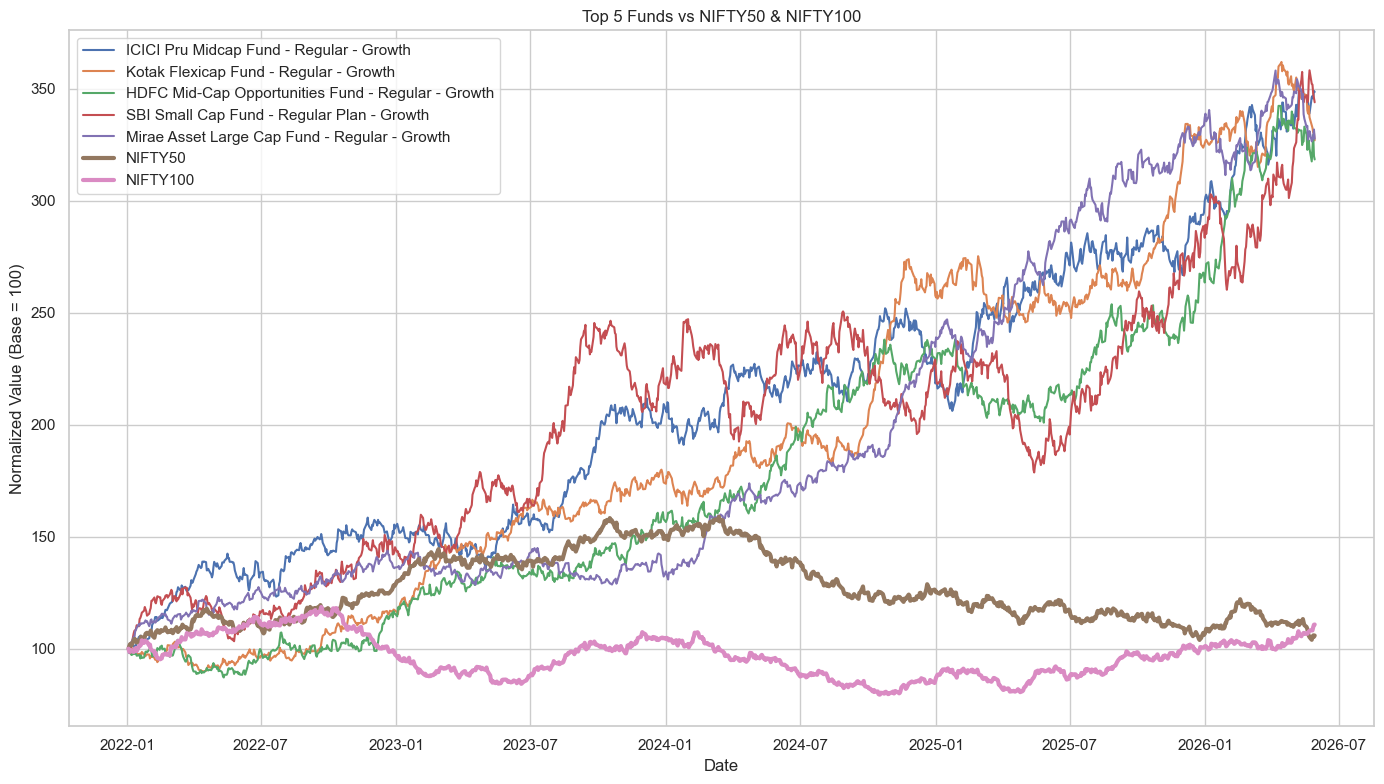

In [40]:
plt.figure(figsize=(14,8))

for fund in top5_funds:

    df = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    df["normalized"] = (
        df["nav"]
        /
        df["nav"].iloc[0]
    ) * 100

    fund_name = fund_master.loc[
        fund_master["amfi_code"] == fund,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        df["date"],
        df["normalized"],
        label=fund_name
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png"
)

plt.show()

In [42]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)
tracking_results = []
for fund in top5_funds:

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ][
        ["date", "daily_return"]
    ]

    merged = pd.merge(
        fund_returns,
        nifty100[
            [
                "date",
                "benchmark_return"
            ]
        ],
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
        *
        np.sqrt(252)
    )

    tracking_results.append(
        [fund, tracking_error]
    )
    tracking_df = pd.DataFrame(
    tracking_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_df

,amfi_code,tracking_error
0,120505,0.231968
1,120843,0.206425
2,100033,0.228699
3,119598,0.283881
4,148567,0.189664


In [43]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)
print("alpha_beta.csv exported successfully")
print("fund_scorecard.csv exported successfully")

alpha_beta.csv exported successfully
fund_scorecard.csv exported successfully


In [44]:
tracking_df

,amfi_code,tracking_error
0,120505,0.231968
1,120843,0.206425
2,100033,0.228699
3,119598,0.283881
4,148567,0.189664
